## A. Metode Tertutup (Bracketing Methods)
Metode tertutup adalah pendekatan pencarian akar yang membutuhkan dua tebakan awal di mana keduanya harus **mengurung** akar persamaan. Artinya, nilai fungsi pada kedua batas interval harus berlawanan tanda ($f(a) \cdot f(b) < 0$). Keunggulan utama metode ini adalah **selalu konvergen** (pasti menemukan akar).

# Mencari Solusi Persamaan Non-Linear
**Tujuan:** Mengimplementasikan dan membandingkan Metode Biseksi dan Metode Regula Falsi dalam menemukan akar persamaan non-linear $f(x) = 3x - e^x$ dan $f(x) = e^x - x^2 + 3x -2$

### 1. Metode Biseksi
Metode pencarian akar yang paling sederhana dengan cara membagi dua interval secara terus-menerus hingga menemukan nilai akar yang mendekati nol atau mencapai batas toleransi.

**Karakteristik:**
- Membutuhkan dua tebakan awal ($a$ dan $b$) yang mengurung akar.
- Laju konvergensi lambat, namun dijamin pasti akan menemukan akar (selalu konvergen).

**Rumus / Pembaruan Titik (c):**
$$c = \frac{a + b}{2}$$
*(Jika $f(a) \cdot f(c) < 0$, maka interval baru adalah $[a, c]$. Jika sebaliknya, interval baru $[c, b]$)*

========= METODE BISEKSI =========
Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)

========= f(x) = 3x - e^x ========
=========== LOG ITERASI ==========
Iterasi  | a          | b          | c          | f(a)       | f(b)       | f(c)      
--------------------------------------------------------------------------------------
0        | 0.000000   | 1.000000   | 0.500000   | -1.000000  | 0.281718   | -0.148721 
1        | 0.500000   | 1.000000   | 0.750000   | -0.148721  | 0.281718   | 0.133000  
2        | 0.500000   | 0.750000   | 0.625000   | -0.148721  | 0.133000   | 0.006754  
3        | 0.500000   | 0.625000   | 0.562500   | -0.148721  | 0.006754   | -0.067555 
4        | 0.562500   | 0.625000   | 0.593750   | -0.067555  | 0.006754   | -0.029516 
5        | 0.593750   | 0.625000   | 0.609375   | -0.029516  | 0.006754   | -0.011156 
6        | 0.609375   | 0.625000   | 0.617188   | -0.011156  | 0.006754   | -0.002145 
7        | 0.617188   | 0.625000   | 0.621094   | -0.002145  

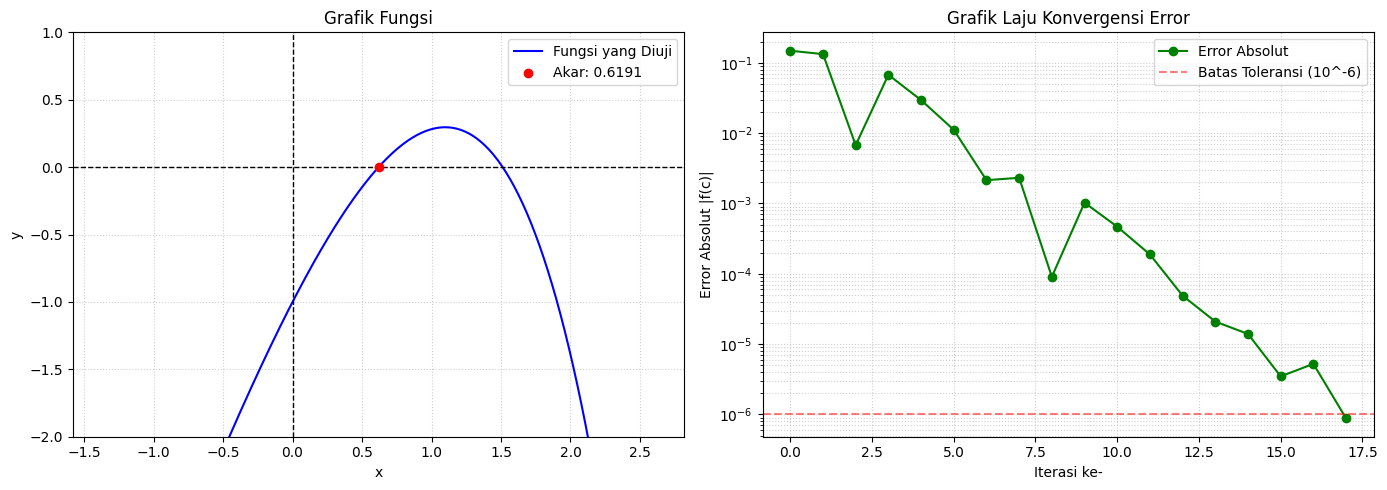


=== f(x) = e^x - x^2 + 3*x - 2 ===
=========== LOG ITERASI ==========
Iterasi  | a          | b          | c          | f(a)       | f(b)       | f(c)      
--------------------------------------------------------------------------------------
0        | 0.000000   | 1.000000   | 0.500000   | -1.000000  | 2.718282   | 0.898721  
1        | 0.000000   | 0.500000   | 0.250000   | -1.000000  | 0.898721   | -0.028475 
2        | 0.250000   | 0.500000   | 0.375000   | -0.028475  | 0.898721   | 0.439366  
3        | 0.250000   | 0.375000   | 0.312500   | -0.028475  | 0.439366   | 0.206682  
4        | 0.250000   | 0.312500   | 0.281250   | -0.028475  | 0.206682   | 0.089433  
5        | 0.250000   | 0.281250   | 0.265625   | -0.028475  | 0.089433   | 0.030564  
6        | 0.250000   | 0.265625   | 0.257812   | -0.028475  | 0.030564   | 0.001066  
7        | 0.250000   | 0.257812   | 0.253906   | -0.028475  | 0.001066   | -0.013699 
8        | 0.253906   | 0.257812   | 0.255859   | -0.013699

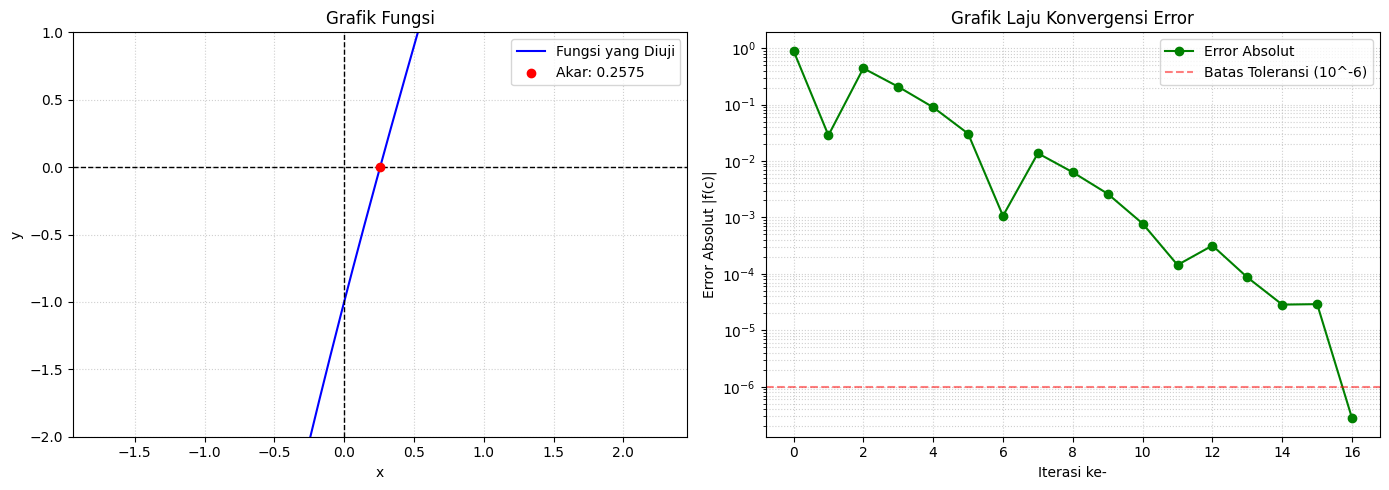

In [ ]:
# @title BISEKSI { display-mode: "form" }

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Definisi fungsi objektif yang akan dicari nilai akarnya (titik potong terhadap sumbu x)
# Persamaan: f(x) = 3x - e^x
def f(x):
    return 3*x - np.exp(x)
# Persamaan: g(x) = e^x - x^2 + 3*x - 2
def g(x):
    return np.exp(x) - x**2 + 3*x - 2


# Visualisasi grafik fungsi dan grafik konvergen

def visualisasi(history, akar_akhir, fg):
    # Membuat figure dengan 2 subplot (grafik fungsi dan grafik konvergensi)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Grafik 1: Visualisasi Fungsi f(x) ---
    # Menentukan rentang x untuk grafik (di sekitar akar yang ditemukan)
    x_range = np.linspace(akar_akhir - 2, akar_akhir + 2, 400)
    y_range = fg(x_range)

    ax1.plot(x_range, y_range, label='Fungsi yang Diuji', color='blue')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.scatter(akar_akhir, fg(akar_akhir), color='red', zorder=5, label=f'Akar: {akar_akhir:.4f}')
    ax1.set_ylim(-2, 1)
    ax1.set_title('Grafik Fungsi')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- Grafik 2: Visualisasi Konvergensi (MODIFIKASI) ---
    error_history = [abs(fg(c)) for c in history]

    ax2.plot(range(len(error_history)), error_history, marker='o', linestyle='-', color='green', label='Error Absolut')

    ax2.axhline(1e-6, color='red', linestyle='--', alpha=0.5, label='Batas Toleransi (10^-6)')

    ax2.set_title('Grafik Laju Konvergensi Error')
    ax2.set_xlabel('Iterasi ke-')
    ax2.set_ylabel('Error Absolut |f(c)|')

    ax2.set_yscale('log')

    ax2.grid(True, which="both", linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# =====================================================================
# KODE (TIDAK ADA YANG DIMODIFIKASI DI BAWAH INI)
# =====================================================================

# 1. Metode Biseksi
# Mencari akar dengan cara membagi dua interval tebakan awal secara berulang.
def input_biseksi():
    print("========= METODE BISEKSI =========")
    # Meminta pengguna memasukkan dua batas interval
    print("Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)")
    a = 0 # float(input("Masukan tebakan akar 1: "))
    b = 1 # float(input("Masukan tebakan akar 2: "))
    print()
    print("========= f(x) = 3x - e^x ========")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'b':<10} | {'c':<10} | {'f(a)':<10} | {'f(b)':<10} | {'f(c)':<10}")
    print("-" * 86)
    biseksi(a, b, f)
    print()
    print("=== f(x) = e^x - x^2 + 3*x - 2 ===")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'b':<10} | {'c':<10} | {'f(a)':<10} | {'f(b)':<10} | {'f(c)':<10}")
    print("-" * 86)
    biseksi(a, b, g)

# Menambahkan parameter eval_count dengan nilai default 0
def biseksi(a, b, fg, n = 0, history=None, eval_count=0):
    if history is None:
        history = [] # Inisialisasi list history pada iterasi awal

    e = 1e-6 # Toleransi error untuk kriteria berhenti (mendekati nol)
    c = (a+b)/2 # Menghitung titik tengah (nilai akar perkiraan)
    fc = fg(c)
    eval_count += 1 # Menghitung 1 evaluasi fungsi untuk fg(c)

    history.append(c)

    # Jika nilai fungsi pada c sudah lebih kecil dari toleransi (sudah sangat dekat dengan 0)
    if abs(fc) < e:
        akar_asli = fsolve(fg, a)[0]
        # 1. Menghitung Galat Sebenarnya
        galat = abs(akar_asli - c)

        # 2. Menghitung Galat Persentase
        galat_persentase = (galat / abs(akar_asli)) * 100

        print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fc:<10.6f}")
        print(f"========== HASIL AKHIR ==========")
        print(f"Akar-akar          : {c}")
        print(f"Akar Asli          : {akar_asli}")
        print(f"Galat Absolut      : {galat:.10f}")
        print(f"Galat Persentase   : {galat_persentase:.10f}%")
        print(f"Iterasi            : {n}")
        print(f"Evaluasi Fungsi    : {eval_count}") # Menampilkan total evaluasi fungsi

        return visualisasi(history, c, fg)
    else:
        eval_count += 2 # Menghitung 2 evaluasi fungsi untuk fg(a) dan fg(b) pada baris di bawah
        # Jika tanda f(a) dan f(b) sama, berarti interval tidak mengurung akar
        if fg(a) * fg(b) > 0:
            print("input tidak valid")
            return input_biseksi() # Meminta input ulang

        eval_count += 1 # Menghitung 1 evaluasi fungsi untuk fg(a) pada baris di bawah
        # Mengecek di sub-interval mana akar berada
        if fg(a) * fc < 0:
            # Akar berada di antara a dan c
            print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fc:<10.6f}")
            return biseksi(a,c, fg, n + 1, history, eval_count)
        else:
            # Akar berada di antara c dan b
            print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fc:<10.6f}")
            return biseksi(c,b, fg, n + 1, history, eval_count)

input_biseksi()

### 2. Metode Regula Falsi
Metode yang memanfaatkan **interpolasi linear** untuk mencari akar. Alih-alih membagi interval tepat di tengah, metode ini menarik garis lurus antara titik $(a, f(a))$ dan $(b, f(b))$ untuk memprediksi letak akar.

**Karakteristik:**
- Membutuhkan dua tebakan awal ($a$ dan $b$) yang mengurung akar.
- Laju konvergensi umumnya lebih cepat dibandingkan Metode Biseksi karena memperhitungkan besaran nilai fungsi.

**Rumus / Pembaruan Titik (c):**
$$c = b - \frac{f(b)(b - a)}{f(b) - f(a)}$$
*(Aturan penggantian batas interval sama seperti metode Biseksi)*

======METODE REGULA FALSI======
Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)

========= f(x) = 3x - e^x ========
=========== LOG ITERASI ==========
Iterasi  | a          | b          | c          | f(a)       | f(b)       | f(c)      
--------------------------------------------------------------------------------------
0        | 1.000000   | 0.000000   | 0.780203   | 0.281718   | -1.000000  | 0.158694  
1        | 0.780203   | 0.000000   | 0.673347   | 0.158694   | -1.000000  | 0.059252  
2        | 0.673347   | 0.000000   | 0.635682   | 0.059252   | -1.000000  | 0.018736  
3        | 0.635682   | 0.000000   | 0.623991   | 0.018736   | -1.000000  | 0.005611  
4        | 0.623991   | 0.000000   | 0.620509   | 0.005611   | -1.000000  | 0.001653  
5        | 0.620509   | 0.000000   | 0.619485   | 0.001653   | -1.000000  | 0.000484  
6        | 0.619485   | 0.000000   | 0.619185   | 0.000484   | -1.000000  | 0.000142  
7        | 0.619185   | 0.000000   | 0.619098   | 0.000142   | -

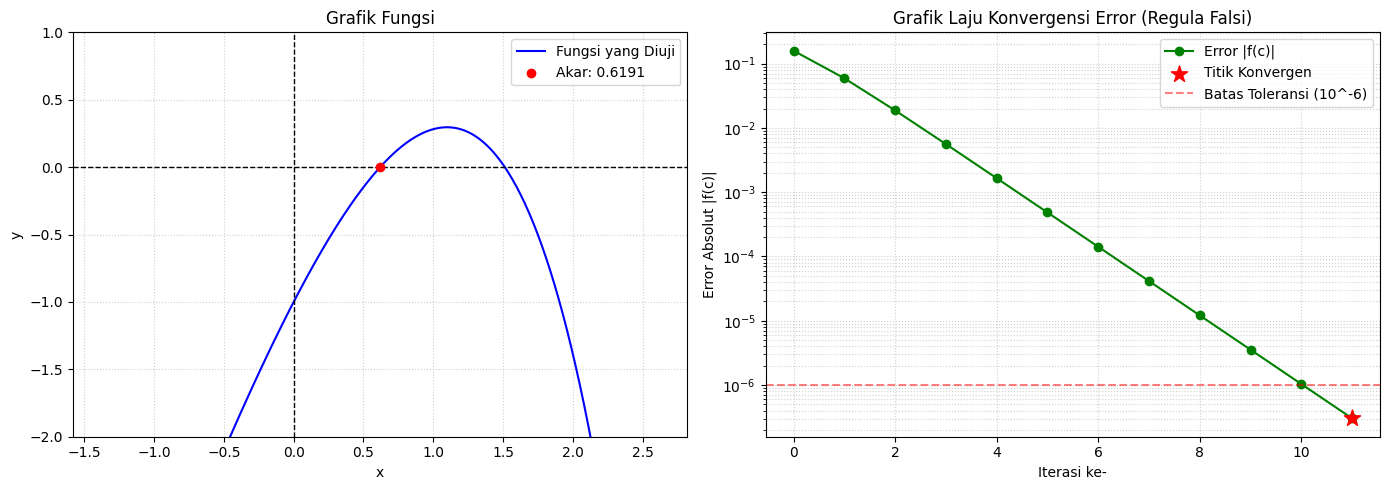


=== f(x) = e^x - x^2 + 3*x - 2 ===
=========== LOG ITERASI ==========
Iterasi  | a          | b          | c          | f(a)       | f(b)       | f(c)      
--------------------------------------------------------------------------------------
0        | 1.000000   | 0.000000   | 0.268941   | 2.718282   | -1.000000  | 0.043073  
1        | 0.268941   | 0.000000   | 0.257836   | 0.043073   | -1.000000  | 0.001154  
2        | 0.257836   | 0.000000   | 0.257538   | 0.001154   | -1.000000  | 0.000031  
3        | 0.257538   | 0.000000   | 0.257531   | 0.000031   | -1.000000  | 0.000001  
========== HASIL AKHIR ==========
Akar-akar          : 0.2575305059798507
Akar Asli          : 0.2575302854398608
Galat Absolut      : 0.0000002205
Galat Persentase   : 0.0000856365%
Iterasi            : 3
Evaluasi Fungsi    : 28


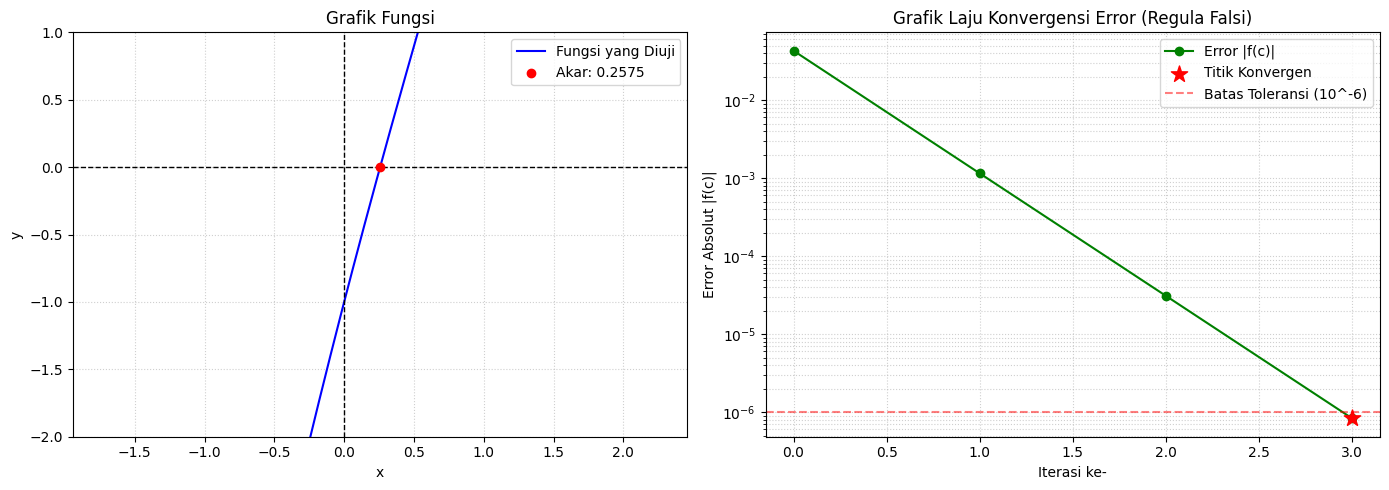

In [ ]:
# @title REGULA FALSI { display-mode: "form" }

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Definisi fungsi objektif yang akan dicari nilai akarnya (titik potong terhadap sumbu x)
# Persamaan: f(x) = 3x - e^x
def f(x):
    return 3*x - np.exp(x)
# Persamaan: g(x) = e^x - x^2 + 3*x - 2
def g(x):
    return np.exp(x) - x**2 + 3*x - 2


# Visualisasi grafik fungsi dan grafik konvergen

def visualisasi(history, akar_akhir, fg):
    # Membuat figure dengan 2 subplot (grafik fungsi dan grafik konvergensi)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Grafik 1: Visualisasi Fungsi f(x) ---
    # Menentukan rentang x untuk grafik (di sekitar akar yang ditemukan)
    x_range = np.linspace(akar_akhir - 2, akar_akhir + 2, 400)
    y_range = fg(x_range)

    ax1.plot(x_range, y_range, label='Fungsi yang Diuji', color='blue')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.scatter(akar_akhir, fg(akar_akhir), color='red', zorder=5, label=f'Akar: {akar_akhir:.4f}')
    ax1.set_ylim(-2, 1)
    ax1.set_title('Grafik Fungsi')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- Grafik 2: Visualisasi Konvergensi ---
    error_history = [abs(fg(c)) for c in history]

    ax2.plot(range(len(error_history)), error_history, marker='o', linestyle='-', color='green', label='Error |f(c)|')

    ax2.scatter(len(error_history)-1, error_history[-1], color='red', s=150, marker='*', zorder=5, label='Titik Konvergen')

    ax2.axhline(1e-6, color='red', linestyle='--', alpha=0.5, label='Batas Toleransi (10^-6)')

    ax2.set_title('Grafik Laju Konvergensi Error (Regula Falsi)')
    ax2.set_xlabel('Iterasi ke-')
    ax2.set_ylabel('Error Absolut |f(c)|')

    ax2.set_yscale('log')

    ax2.grid(True, which="both", linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# =====================================================================
# KODE
# =====================================================================

# 2. Metode Regula Falsi
# Mirip biseksi, namun titik potong baru dihitung menggunakan interpolasi linear (garis lurus) antara f(a) dan f(b).

def input_regulafalsi():
    print("======METODE REGULA FALSI======")
    print("Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)")
    a = 1 # float(input("Masukan tebakan akar 1: "))
    b = 0 # float(input("Masukan tebakan akar 2: "))
    print()
    print("========= f(x) = 3x - e^x ========")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'b':<10} | {'c':<10} | {'f(a)':<10} | {'f(b)':<10} | {'f(c)':<10}")
    print("-" * 86)
    regula_falsi(a, b, f)
    print()
    print("=== f(x) = e^x - x^2 + 3*x - 2 ===")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'b':<10} | {'c':<10} | {'f(a)':<10} | {'f(b)':<10} | {'f(c)':<10}")
    print("-" * 86)
    regula_falsi(a, b, g)

# Menambahkan parameter eval_count dengan nilai default 0
def regula_falsi(a, b, fg, n = 0, history = None, eval_count = 0):
    if history is None:
        history = [] # Inisialisasi list history pada iterasi awal

    n_max = 100 # Batas maksimal iterasi untuk mencegah rekursi tak terbatas (infinite loop)
    if n > n_max:
        return f"Gagal konvergen setelah {n_max} iterasi."

    e = 1e-6 # Toleransi error
    # Menghitung titik c menggunakan rumus Regula Falsi
    c = b - ((fg(b) *(b -a))/(fg(b) - fg(a)))
    eval_count += 3 # Terdapat 3 pemanggilan fungsi di baris atas: fg(b) dua kali, dan fg(a) sekali

    history.append(c)

    # Kriteria berhenti
    eval_count += 1 # Pemanggilan fungsi fg(c) pada kondisi if di bawah
    if abs(fg(c)) < e:
        akar_asli = fsolve(fg, a)[0]
        # 1. Menghitung Galat Sebenarnya
        galat = abs(akar_asli - c)

        # 2. Menghitung Galat Persentase
        galat_persentase = (galat / abs(akar_asli)) * 100

        print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fg(c):<10.6f}")
        print(f"========== HASIL AKHIR ==========")
        print(f"Akar-akar          : {c}")
        print(f"Akar Asli          : {akar_asli}")
        print(f"Galat Absolut      : {galat:.10f}")
        print(f"Galat Persentase   : {galat_persentase:.10f}%")
        print(f"Iterasi            : {n}")
        print(f"Evaluasi Fungsi    : {eval_count}") # Menampilkan total evaluasi fungsi

        return visualisasi(history, c, fg)
    else:
        eval_count += 2 # Pemanggilan fg(a) dan fg(b) pada kondisi if di bawah
        # Pengecekan apakah akar terkurung
        if fg(a) * fg(b) > 0:
            print("input tidak valid")
            return input_regulafalsi()

        eval_count += 2 # Pemanggilan fg(a) dan fg(c) pada kondisi if di bawah
        # Mempersempit interval
        if fg(a) * fg(c) < 0:
            print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fg(c):<10.6f}")
            return regula_falsi(a,c,fg, n + 1, history, eval_count)
        else:
            print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fg(c):<10.6f}")
            return regula_falsi(c,b,fg, n + 1, history, eval_count)


input_regulafalsi()

## B. Metode Terbuka
Metode terbuka adalah pendekatan yang tidak memerlukan tebakan awal yang mengurung akar. Metode ini bisa dimulai dari satu atau dua titik di mana saja. Kelemahannya adalah **bisa divergen** (gagal menemukan akar), tetapi jika berhasil, laju konvergensinya **jauh lebih cepat** dari metode tertutup.

### 1. Metode Newton-Raphson
Metode yang menggunakan gradien (garis singgung atau turunan pertama) dari fungsi pada suatu titik awal untuk memproyeksikan titik potong baru di sumbu-x.

**Karakteristik:**
- Hanya membutuhkan satu tebakan awal ($x_0$).
- Memerlukan perhitungan rumus turunan analitik pertama dari fungsi, yaitu $f'(x)$.
- Konvergensi sangat cepat, tetapi bisa gagal (divergen) jika tebakan awal terlalu jauh atau nilai turunan mendekati nol.

**Rumus Iterasi:**
$$x_{i+1} = x_i - \frac{f(x_i)}{f'(x_i)}$$

======METODE NEWTON RAPHSON======
Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)

========= f(x) = 3x - e^x ========
=========== LOG ITERASI ==========
Iterasi  | a          | f(a)       | f'(a)      | c          | f(c)      
-------------------------------------------------------------------------
0        | 0.000000   | -1.000000  | 2.000000   | 0.500000   | -0.148721 
1        | 0.500000   | -0.148721  | 1.351279   | 0.610060   | -0.010362 
2        | 0.610060   | -0.010362  | 1.159459   | 0.618997   | -0.000074 
3        | 0.618997   | -0.000074  | 1.142936   | 0.619061   | -0.000000 
========== HASIL AKHIR ==========
Akar-akar          : 0.6190612833560798
Akar Asli          : 0.619061286735768
Galat Absolut      : 0.0000000034
Galat Persentase   : 0.0000005459%
Iterasi            : 3
Evaluasi Fungsi    : 16


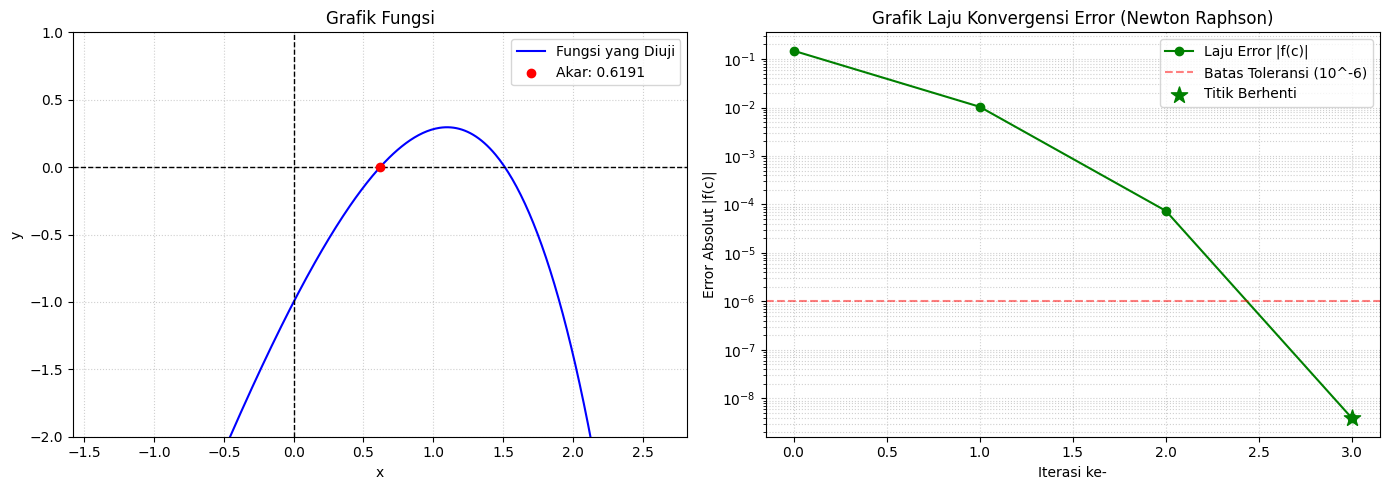


=== f(x) = e^x - x^2 + 3*x - 2 ===
=========== LOG ITERASI ==========
Iterasi  | a          | f(a)       | f'(a)      | c          | f(c)      
-------------------------------------------------------------------------
0        | 0.000000   | -1.000000  | 4.000000   | 0.250000   | -0.028475 
1        | 0.250000   | -0.028475  | 3.784025   | 0.257525   | -0.000020 
2        | 0.257525   | -0.000020  | 3.778674   | 0.257530   | -0.000000 
========== HASIL AKHIR ==========
Akar-akar          : 0.25753028543719086
Akar Asli          : 0.25753028543986073
Galat Absolut      : 0.0000000000
Galat Persentase   : 0.0000000010%
Iterasi            : 2
Evaluasi Fungsi    : 12


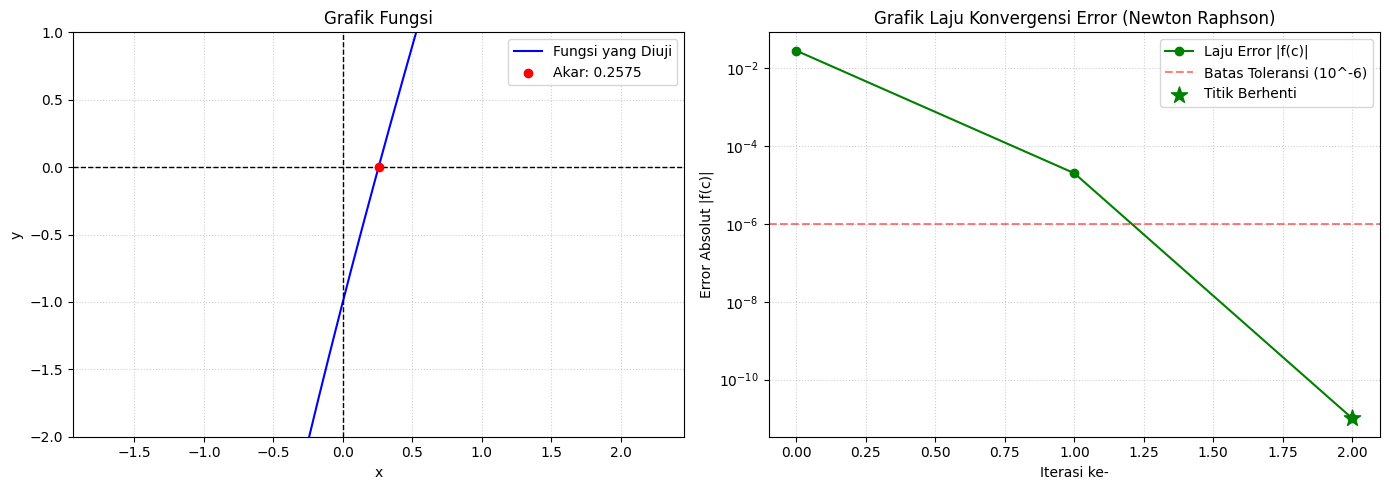

In [ ]:
# @title NEWTON RAPHSON { display-mode: "form" }

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Definisi fungsi objektif yang akan dicari nilai akarnya (titik potong terhadap sumbu x)
# Persamaan: f(x) = 3x - e^x
def f(x):
    return 3*x - np.exp(x)
# Persamaan: f(x) = e^x - x^2 + 3*x - 2
def g(x):
    return np.exp(x) - x**2 + 3*x - 2


# Visualisasi grafik fungsi dan grafik konvergen

def visualisasi(history, akar_akhir, fg):
    # Membuat figure dengan 2 subplot (grafik fungsi dan grafik konvergensi)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Grafik 1: Visualisasi Fungsi f(x) ---
    # Menentukan rentang x untuk grafik (di sekitar akar yang ditemukan)
    x_range = np.linspace(akar_akhir - 2, akar_akhir + 2, 400)
    y_range = fg(x_range)

    ax1.plot(x_range, y_range, label='Fungsi yang Diuji', color='blue')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.scatter(akar_akhir, fg(akar_akhir), color='red', zorder=5, label=f'Akar: {akar_akhir:.4f}')
    ax1.set_ylim(-2, 1)
    ax1.set_title('Grafik Fungsi')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- Grafik 2: Visualisasi Konvergensi (DIMODIFIKASI KE SKALA LOGARITMIK) ---
    errors = [abs(fg(c)) for c in history]

    ax2.plot(range(len(errors)), errors, marker='o', linestyle='-', color='green', label='Laju Error |f(c)|')

    ax2.set_yscale('log')

    ax2.axhline(1e-6, color='red', linestyle='--', alpha=0.5, label='Batas Toleransi (10^-6)')

    ax2.scatter(len(errors)-1, errors[-1], color='green', s=150, marker='*', zorder=5, label='Titik Berhenti')

    ax2.set_title('Grafik Laju Konvergensi Error (Newton Raphson)')
    ax2.set_xlabel('Iterasi ke-')
    ax2.set_ylabel('Error Absolut |f(c)|')

    ax2.grid(True, which="both", linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# =====================================================================
# KODE
# =====================================================================

# 1. Newton Raphson
# Memanfaatkan nilai turunan pertama fungsi (gradien) untuk mencari titik potong sumbu x selanjutnya.
def input_newtonraphson():
    print("======METODE NEWTON RAPHSON======")
    # Hanya membutuhkan satu nilai tebakan awal
    print("Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)")
    a = 0 # float(input("Masukan tebakan akar 1: "))
    print()
    print("========= f(x) = 3x - e^x ========")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'f(a)':<10} | {'f\'(a)':<10} | {'c':<10} | {'f(c)':<10}")
    print("-" * 73)
    newton_raphson(a, f)
    print()
    print("=== f(x) = e^x - x^2 + 3*x - 2 ===")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'f(a)':<10} | {'f\'(a)':<10} | {'c':<10} | {'f(c)':<10}")
    print("-" * 73)
    newton_raphson(a, g)

# Menambahkan parameter eval_count dengan nilai default 0
def newton_raphson(a, fg, n=0, history=None, eval_count=0):
    if history is None:
        history = [] # Inisialisasi list history pada iterasi awal

    n_max = 100 # Batas maksimal iterasi untuk mencegah rekursi tak terbatas (infinite loop)
    if n > n_max:
        return f"Gagal konvergen setelah {n_max} iterasi."

    e = 1e-6 # Toleransi error
    h = 1e-8 # Nilai h untuk pendekatan numerik turunan pertama

    # Mencari nilai turunan f'(a)
    f_prime = (fg(a+h) - fg(a))/h
    eval_count += 2 # Menghitung 2 evaluasi fungsi untuk fg(a+h) dan fg(a)

    # Mencari nilai x baru menggunakan rumus iterasi Newton-Raphson: x1 = x0 - (f(x0)/f'(x0))
    c = a - (fg(a)/f_prime)
    eval_count += 1 # Menghitung 1 evaluasi fungsi untuk fg(a)

    history.append(c)

    # Kriteria berhenti
    eval_count += 1 # Menghitung 1 evaluasi fungsi untuk fg(c) di bawah ini
    if abs(fg(c)) < e:
        akar_asli = fsolve(fg, a)[0]
        # 1. Menghitung Galat Sebenarnya
        galat = abs(akar_asli - c)

        # 2. Menghitung Galat Persentase
        galat_persentase = (galat / abs(akar_asli)) * 100

        print(f"{n:<8} | {a:<10.6f} | {fg(a):<10.6f} | {f_prime:<10.6f} | {c:<10.6f} | {fg(c):<10.6f}")
        print(f"========== HASIL AKHIR ==========")
        print(f"Akar-akar          : {c}")
        print(f"Akar Asli          : {akar_asli}")
        print(f"Galat Absolut      : {galat:.10f}")
        print(f"Galat Persentase   : {galat_persentase:.10f}%")
        print(f"Iterasi            : {n}")
        print(f"Evaluasi Fungsi    : {eval_count}") # Menampilkan total evaluasi fungsi

        return visualisasi(history, c, fg)

    else:
        # Melanjutkan iterasi dengan tebakan akar yang baru (c)
        print(f"{n:<8} | {a:<10.6f} | {fg(a):<10.6f} | {f_prime:<10.6f} | {c:<10.6f} | {fg(c):<10.6f}")
        return newton_raphson(c,fg, n+1, history, eval_count) # Meneruskan eval_count ke iterasi berikutnya


input_newtonraphson()

### 2. Metode Secant
Modifikasi dari metode Newton-Raphson. Metode ini menggunakan garis potong (secant) yang menghubungkan dua titik untuk menaksir nilai turunan fungsi secara numerik.

**Karakteristik:**
- Membutuhkan dua tebakan awal ($x_0$ dan $x_1$), tetapi tidak harus mengurung akar.
- Tidak memerlukan perhitungan rumus turunan analitik $f'(x)$, sehingga sangat cocok untuk fungsi yang sulit diturunkan.
- Konvergensi cepat (hampir menyamai Newton-Raphson).

**Rumus Iterasi:**
$$x_{i+1} = x_i - \frac{f(x_i)(x_i - x_{i-1})}{f(x_i) - f(x_{i-1})}$$

======METODE SECANT======
Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)

========= f(x) = 3x - e^x ========
=========== LOG ITERASI ==========
Iterasi  | a          | b          | c          | f(a)       | f(b)       | f(c)      
--------------------------------------------------------------------------------------
0        | 1.000000   | 0.000000   | 0.780203   | 0.281718   | -1.000000  | 0.158694  
1        | 0.000000   | 0.780203   | 0.673347   | -1.000000  | 0.158694   | 0.059252  
2        | 0.780203   | 0.673347   | 0.609678   | 0.158694   | 0.059252   | -0.010805 
3        | 0.673347   | 0.609678   | 0.619498   | 0.059252   | -0.010805  | 0.000499  
4        | 0.609678   | 0.619498   | 0.619065   | -0.010805  | 0.000499   | 0.000004  
5        | 0.619498   | 0.619065   | 0.619061   | 0.000499   | 0.000004   | -0.000000 
========== HASIL AKHIR ==========
Akar-akar          : 0.6190612855673235
Akar Asli          : 0.6190612867359451
Galat Absolut      : 0.0000000012
Galat Per

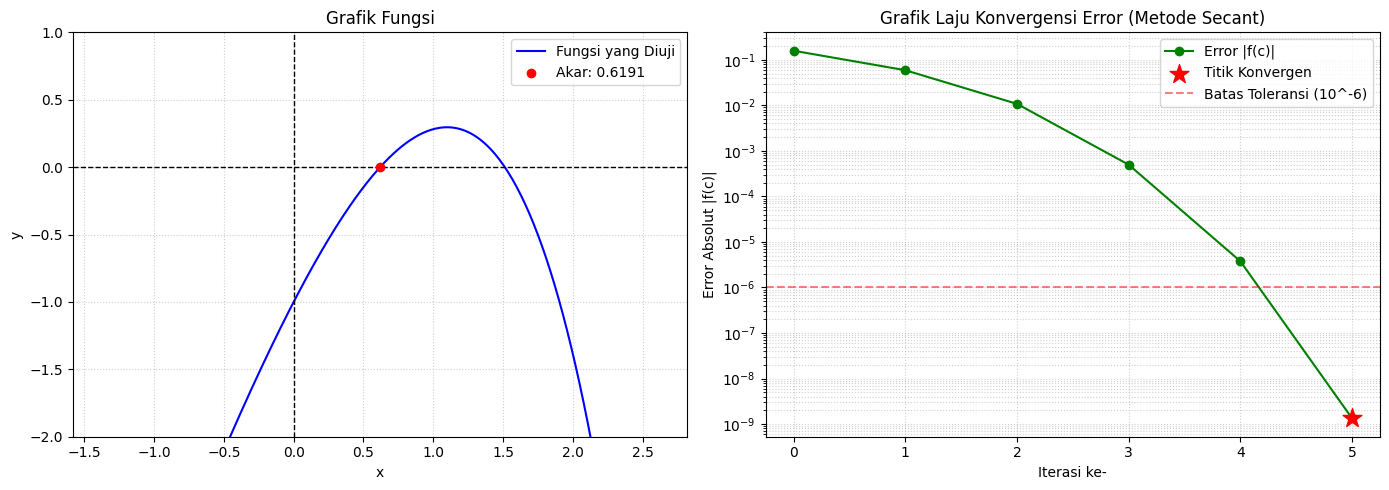


=== f(x) = e^x - x^2 + 3*x - 2 ===
=========== LOG ITERASI ==========
Iterasi  | a          | b          | c          | f(a)       | f(b)       | f(c)      
--------------------------------------------------------------------------------------
0        | 1.000000   | 0.000000   | 0.268941   | 2.718282   | -1.000000  | 0.043073  
1        | 0.000000   | 0.268941   | 0.257836   | -1.000000  | 0.043073   | 0.001154  
2        | 0.268941   | 0.257836   | 0.257530   | 0.043073   | 0.001154   | -0.000001 
3        | 0.257836   | 0.257530   | 0.257530   | 0.001154   | -0.000001  | 0.000000  
========== HASIL AKHIR ==========
Akar-akar          : 0.257530285449093
Akar Asli          : 0.25753028543986073
Galat Absolut      : 0.0000000000
Galat Persentase   : 0.0000000036%
Iterasi            : 3
Evaluasi Fungsi    : 16


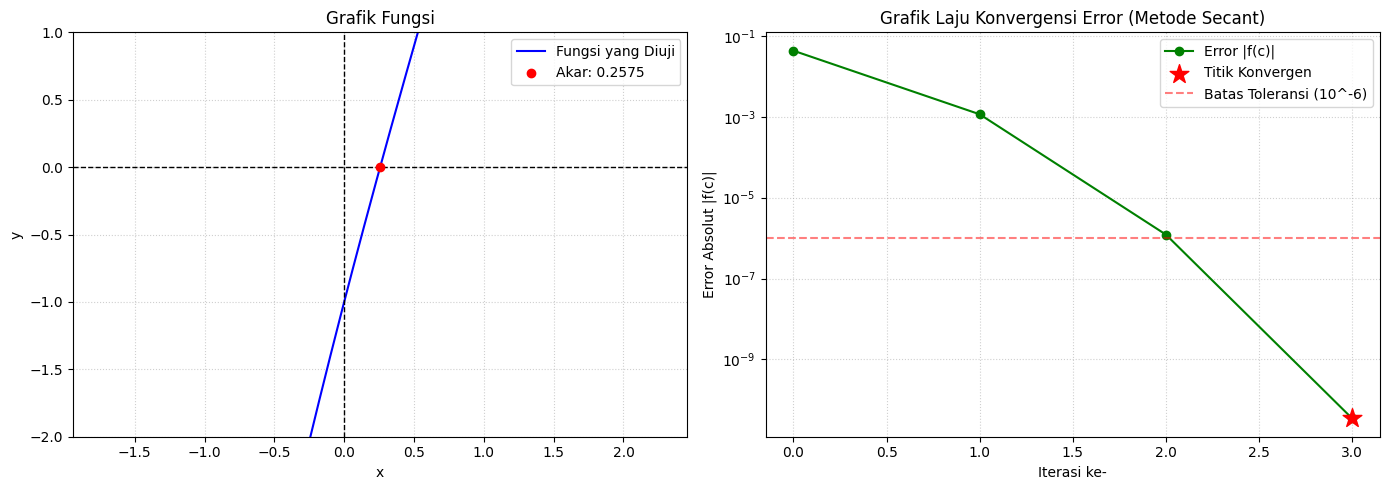

In [ ]:
# @title SECANT { display-mode: "form" }

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve

# Definisi fungsi objektif yang akan dicari nilai akarnya (titik potong terhadap sumbu x)
# Persamaan: f(x) = 3x - e^x
def f(x):
    return 3*x - np.exp(x)
# Persamaan: f(x) = e^x - x^2 + 3*x - 2
def g(x):
    return np.exp(x) - x**2 + 3*x - 2


# Visualisasi grafik fungsi dan grafik konvergen

def visualisasi(history, akar_akhir, fg):
    # Membuat figure dengan 2 subplot (grafik fungsi dan grafik konvergensi)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Grafik 1: Visualisasi Fungsi f(x) ---
    # Menentukan rentang x untuk grafik (di sekitar akar yang ditemukan)
    x_range = np.linspace(akar_akhir - 2, akar_akhir + 2, 400)
    y_range = fg(x_range)

    ax1.plot(x_range, y_range, label='Fungsi yang Diuji', color='blue')
    ax1.axhline(0, color='black', linestyle='--', linewidth=1)
    ax1.axvline(0, color='black', linestyle='--', linewidth=1)
    ax1.scatter(akar_akhir, fg(akar_akhir), color='red', zorder=5, label=f'Akar: {akar_akhir:.4f}')
    ax1.set_ylim(-2, 1)
    ax1.set_title('Grafik Fungsi')
    ax1.set_xlabel('x')
    ax1.set_ylabel('y')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- Grafik 2: Visualisasi Konvergensi ---
    error_history = [abs(fg(c)) for c in history]

    ax2.plot(range(len(error_history)), error_history, marker='o', linestyle='-', color='green', label='Error |f(c)|')

    ax2.scatter(len(error_history)-1, error_history[-1], color='red', s=200, marker='*', zorder=5, label='Titik Konvergen')

    ax2.axhline(1e-6, color='red', linestyle='--', alpha=0.5, label='Batas Toleransi (10^-6)')

    ax2.set_title('Grafik Laju Konvergensi Error (Metode Secant)')
    ax2.set_xlabel('Iterasi ke-')
    ax2.set_ylabel('Error Absolut |f(c)|')

    ax2.set_yscale('log')

    ax2.grid(True, which="both", linestyle=':', alpha=0.6)
    ax2.legend()

    plt.tight_layout()
    plt.show()

# =====================================================================
# KODE
# =====================================================================

# 2. Secant
# Modifikasi dari Newton Raphson, di mana turunan pertama didekati menggunakan garis potong (secant line) dari dua titik sebelumnya.
def input_secant():
    print("======METODE SECANT======")
    print("Tebakan akar antara 0 ≤ x ≤ 1 (Berdasarkan tugas)")
    a = 1 #float(input("Masukan tebakan akar 1: "))
    b = 0 # float(input("Masukan tebakan akar 2: "))
    print()
    print("========= f(x) = 3x - e^x ========")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'b':<10} | {'c':<10} | {'f(a)':<10} | {'f(b)':<10} | {'f(c)':<10}")
    print("-" * 86)
    secant(a, b, f)
    print()
    print("=== f(x) = e^x - x^2 + 3*x - 2 ===")
    print("=========== LOG ITERASI ==========")
    print(f"{'Iterasi':<8} | {'a':<10} | {'b':<10} | {'c':<10} | {'f(a)':<10} | {'f(b)':<10} | {'f(c)':<10}")
    print("-" * 86)
    secant(a, b, g)

# Menambahkan parameter eval_count dengan nilai default 0
def secant(a, b, fg, n = 0, history=None, eval_count=0):
    if history is None:
        history = [] # Inisialisasi list history pada iterasi awal

    n_max = 100 # Batas maksimal iterasi untuk mencegah rekursi tak terbatas (infinite loop)
    if n > n_max:
        return f"Gagal konvergen setelah {n_max} iterasi."

    e = 1e-6 # Toleransi error
    # Menghitung x baru menggunakan rumus Secant
    c = b - ((fg(b) *(b -a))/(fg(b) - fg(a)))
    eval_count += 3 # Menghitung 3 evaluasi fungsi: fg(a) dipanggil 1x, fg(b) dipanggil 2x

    history.append(c)

    # Kriteria berhenti
    eval_count += 1 # Menghitung 1 evaluasi fungsi untuk fg(c) pada kondisi if di bawah
    if abs(fg(c)) < e:
        akar_asli = fsolve(fg, a)[0]
        # 1. Menghitung Galat Sebenarnya
        galat = abs(akar_asli - c)

        # 2. Menghitung Galat Persentase
        galat_persentase = (galat / abs(akar_asli)) * 100

        print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fg(c):<10.6f}")
        print(f"========== HASIL AKHIR ==========")
        print(f"Akar-akar          : {c}")
        print(f"Akar Asli          : {akar_asli}")
        print(f"Galat Absolut      : {galat:.10f}")
        print(f"Galat Persentase   : {galat_persentase:.10f}%")
        print(f"Iterasi            : {n}")
        print(f"Evaluasi Fungsi    : {eval_count}") # Menampilkan total evaluasi fungsi

        return visualisasi(history, c, fg)
    else:
        # Melanjutkan iterasi dengan dua titik terakhir: b dan c
        print(f"{n:<8} | {a:<10.6f} | {b:<10.6f} | {c:<10.6f} | {fg(a):<10.6f} | {fg(b):<10.6f} | {fg(c):<10.6f}")
        return secant(b, c, fg, n + 1, history, eval_count) # Meneruskan eval_count ke iterasi berikutnya

input_secant()

### Kesimpulan Analisis Laju Konvergensi Metode Pencarian Akar

Grafik logaritmik menunjukkan dengan jelas seberapa cepat setiap metode menekan nilai error mendekati batas toleransi ($10^{-6}$). Berdasarkan kemiringan kurva (semakin curam berarti semakin cepat turun), urutan kecepatan metode dari yang paling cepat hingga paling lambat adalah:
* **Newton-Raphson:** Kurvanya menukik sangat tajam ke bawah, yang berarti metode ini membutuhkan jumlah iterasi paling sedikit untuk mencapai target toleransi.
* **Secant:** Grafiknya sangat menempel atau hanya tertinggal 1-2 iterasi di belakang Newton-Raphson. Ini membuktikan bahwa Secant adalah alternatif yang sangat efisien jika turunan fungsi sulit dicari.
* **Regula Falsi:** Meskipun memanfaatkan nilai fungsi untuk menebak akar, kecepatannya sangat bergantung pada kelengkungan grafik dan rentan melambat jika salah satu titik interval tidak bergeser.
* **Biseksi:** Kurvanya membentuk garis lurus yang menurun secara perlahan dan teratur, sehingga membutuhkan iterasi paling banyak (sekitar 20 iterasi dari rentang [0, 1]).


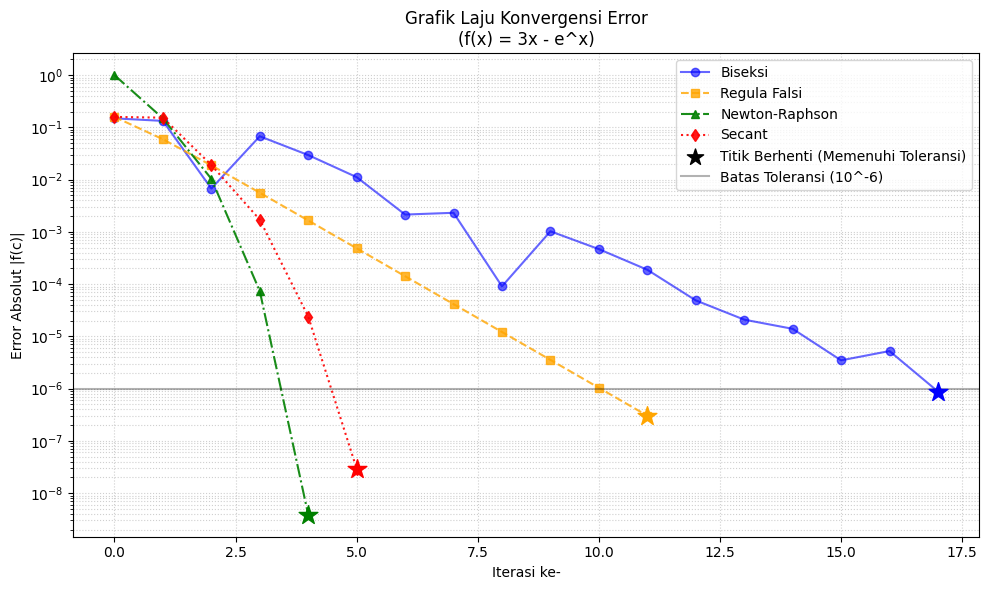

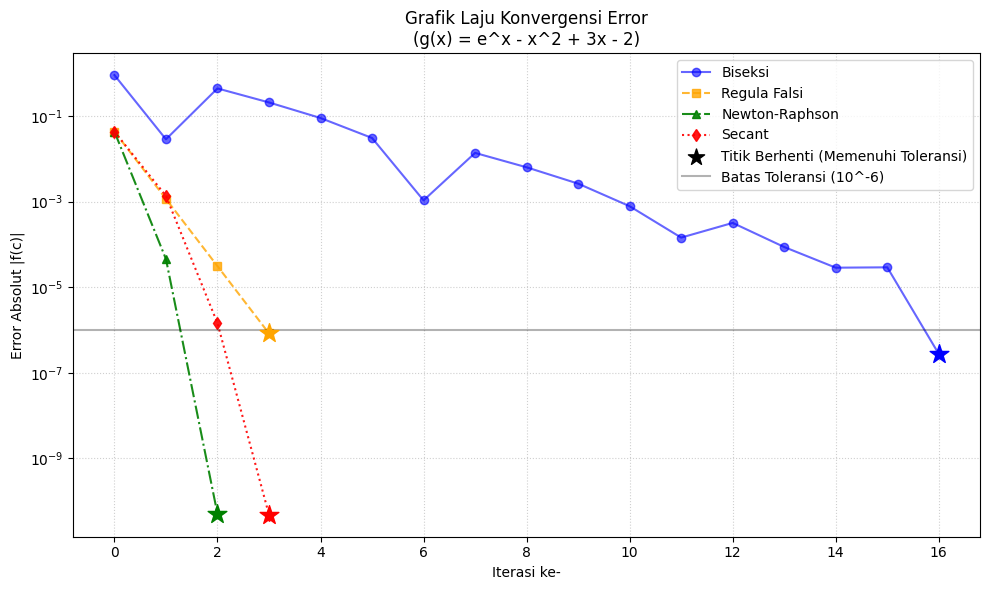

In [ ]:
# @title PERBANDINGAN GRAFIK { display-mode: "form" }

import matplotlib.pyplot as plt
import numpy as np

# --- Grafik Visualisasi Konvergensi Gabungan (Skala Logaritmik Error) ---
def visualisasi(hist_biseksi, hist_regula, hist_newton, hist_secant, judul_fungsi, fg):
    plt.figure(figsize=(10, 6))

    # Fungsi pembantu untuk mengubah nilai akar (c) menjadi nilai error absolut |f(c)|
    def hitung_error(history):
        return [abs(fg(c)) for c in history]

    # Plotting error dengan skala logaritmik
    if hist_biseksi:
        err_biseksi = hitung_error(hist_biseksi)
        plt.plot(range(len(err_biseksi)), err_biseksi, marker='o', linestyle='-', label='Biseksi', color='blue', alpha=0.6)
        plt.scatter(len(err_biseksi)-1, err_biseksi[-1], color='blue', s=200, marker='*', zorder=5)

    if hist_regula:
        err_regula = hitung_error(hist_regula)
        plt.plot(range(len(err_regula)), err_regula, marker='s', linestyle='--', label='Regula Falsi', color='orange', alpha=0.8)
        plt.scatter(len(err_regula)-1, err_regula[-1], color='orange', s=200, marker='*', zorder=5)

    if hist_newton:
        err_newton = hitung_error(hist_newton)
        plt.plot(range(len(err_newton)), err_newton, marker='^', linestyle='-.', label='Newton-Raphson', color='green', alpha=0.9)
        plt.scatter(len(err_newton)-1, err_newton[-1], color='green', s=200, marker='*', zorder=5)

    if hist_secant:
        err_secant = hitung_error(hist_secant)
        plt.plot(range(len(err_secant)), err_secant, marker='d', linestyle=':', label='Secant', color='red', alpha=0.9)
        plt.scatter(len(err_secant)-1, err_secant[-1], color='red', s=200, marker='*', zorder=5)

    plt.scatter([], [], color='black', s=150, marker='*', label='Titik Berhenti (Memenuhi Toleransi)')

    plt.title(f'Grafik Laju Konvergensi Error\n({judul_fungsi})')
    plt.xlabel('Iterasi ke-')
    plt.ylabel('Error Absolut |f(c)|')

    # MENGUBAH SUMBU Y MENJADI SKALA LOGARITMIK (10^-1, 10^-2, dst)
    plt.yscale('log')

    # Menambahkan garis batas toleransi error (1e-6)
    plt.axhline(1e-6, color='black', linestyle='-', alpha=0.3, label='Batas Toleransi (10^-6)')

    plt.grid(True, which="both", linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Definisi fungsi objektif yang akan dicari nilai akarnya (titik potong terhadap sumbu x)
def f(x):
    return 3*x - np.exp(x)

def g(x):
    return np.exp(x) - x**2 + 3*x - 2

def biseksi(a, b, fg, n=0, history=None):
    if history is None:
        history = []

    e = 1e-6
    c = (a+b)/2
    history.append(c)

    if abs(fg(c)) < e:
        return
    else:
        if fg(a) * fg(b) > 0:
            return "Input Tidak Valid"

        if fg(a) * fg(c) < 0:
            return biseksi(a, c, fg, n + 1, history)
        else:
            return biseksi(c, b, fg, n + 1, history)

def regula_falsi(a, b, fg, n=0, history=None):
    if history is None:
        history = []

    n_max = 100
    if n > n_max:
        return f"Gagal konvergen setelah {n_max} iterasi."

    e = 1e-6
    c = b - ((fg(b) * (b - a)) / (fg(b) - fg(a)))
    history.append(c)

    if abs(fg(c)) < e:
        return
    else:
        if fg(a) * fg(b) > 0:
            return "Input Tidak Valid"

        if fg(a) * fg(c) < 0:
            return regula_falsi(a, c, fg, n + 1, history)
        else:
            return regula_falsi(c, b, fg, n + 1, history)

def newton_raphson(a, fg, n=0, history=None):
    if history is None:
        history = []

    n_max = 100
    if n > n_max:
        return f"Gagal konvergen setelah {n_max} iterasi."

    e = 1e-6
    h = 1e-8

    f_prime = (fg(a+h) - fg(a))/h

    c = a - (fg(a)/f_prime)
    history.append(c)

    if abs(fg(c)) < e:
        return (f"Akar-akar: {c}\nIterasi: {n}")
    else:
        return newton_raphson(c, fg, n+1, history)

def secant(a, b, fg, n=0, history=None):
    if history is None:
        history = []

    n_max = 100
    if n > n_max:
        return f"Gagal konvergen setelah {n_max} iterasi."

    e = 1e-6
    c = b - ((fg(b) * (b - a)) / (fg(b) - fg(a)))
    history.append(c)

    if abs(fg(c)) < e:
        return (f"Akar-akar: {c}\nIterasi: {n}")
    else:
        return secant(b, c, fg, n + 1, history)

def eksekusi_program():
    a = 0
    b = 1

    # --- Analisis dan visualisasi untuk fungsi f(x) ---
    hist_bis_f, hist_reg_f, hist_new_f, hist_sec_f = [], [], [], []

    biseksi(a, b, f, 0, hist_bis_f)
    regula_falsi(a, b, f, 0, hist_reg_f)
    newton_raphson(b, f, 0, hist_new_f)
    secant(a, b, f, 0, hist_sec_f)

    # Menambahkan argumen fungsi f agar bisa dihitung error-nya di visualisasi
    visualisasi(hist_bis_f, hist_reg_f, hist_new_f, hist_sec_f, "f(x) = 3x - e^x", f)

    # --- Analisis dan visualisasi untuk fungsi g(x) ---
    hist_bis_g, hist_reg_g, hist_new_g, hist_sec_g = [], [], [], []

    biseksi(a, b, g, 0, hist_bis_g)
    regula_falsi(a, b, g, 0, hist_reg_g)
    newton_raphson(b, g, 0, hist_new_g)
    secant(a, b, g, 0, hist_sec_g)

    # Menambahkan argumen fungsi g agar bisa dihitung error-nya di visualisasi
    visualisasi(hist_bis_g, hist_reg_g, hist_new_g, hist_sec_g, "g(x) = e^x - x^2 + 3x - 2", g)

# Jalankan kode
eksekusi_program()